In [1]:
import pandas as pd

# Load your data
df = pd.read_csv('dataset.csv')

# 1. Overall Churn Rate
churn_rate = df['Churned'].mean() * 100
print(f"Overall Churn Rate: {churn_rate:.2f}%")

# 2. Segmenting by Churn (The 'Why')
# We want to see how Churned vs Retained users behave
analysis_cols = ['Login_Frequency', 'Customer_Service_Calls', 'Discount_Usage_Rate', 'Days_Since_Last_Purchase', 'Average_Order_Value']
health_check = df.groupby('Churned')[analysis_cols].mean()
print(health_check)

# 3. LTV Lost (Business Impact)
total_ltv_lost = df[df['Churned'] == 1]['Lifetime_Value'].sum()
print(f"Total Revenue Lost to Churn: ${total_ltv_lost:,.2f}")

# 4. Check for 'Missingness' (PMs need to know if the data is reliable)
print(df.isnull().sum())

Overall Churn Rate: 28.90%
         Login_Frequency  Customer_Service_Calls  Discount_Usage_Rate  \
Churned                                                                 
0              12.642391                5.185458            43.053423   
1               9.120830                6.904378            39.424370   

         Days_Since_Last_Purchase  Average_Order_Value  
Churned                                                 
0                       26.892026           118.383907  
1                       36.942135           134.762532  
Total Revenue Lost to Churn: $20,597,365.76
Age                              2495
Gender                              0
Country                             0
City                                0
Membership_Years                    0
Login_Frequency                     0
Session_Duration_Avg             3399
Pages_Per_Session                3000
Cart_Abandonment_Rate               0
Wishlist_Items                   4000
Total_Purchases             

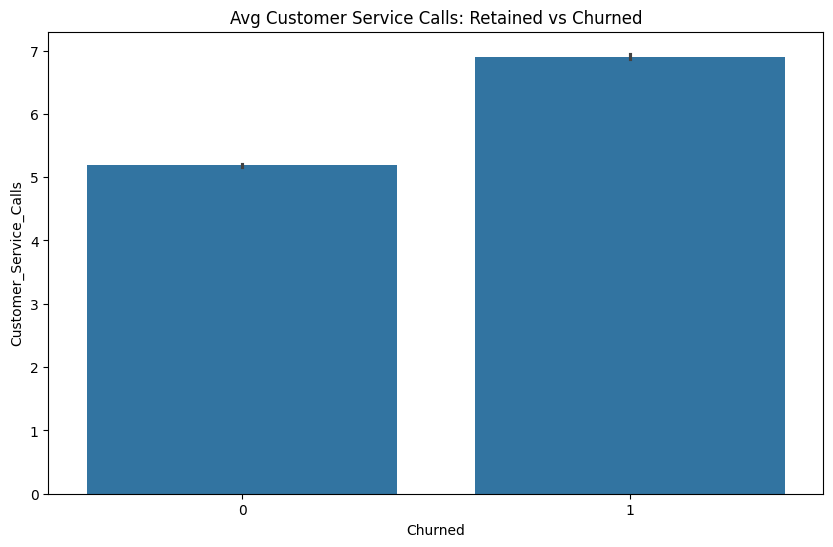

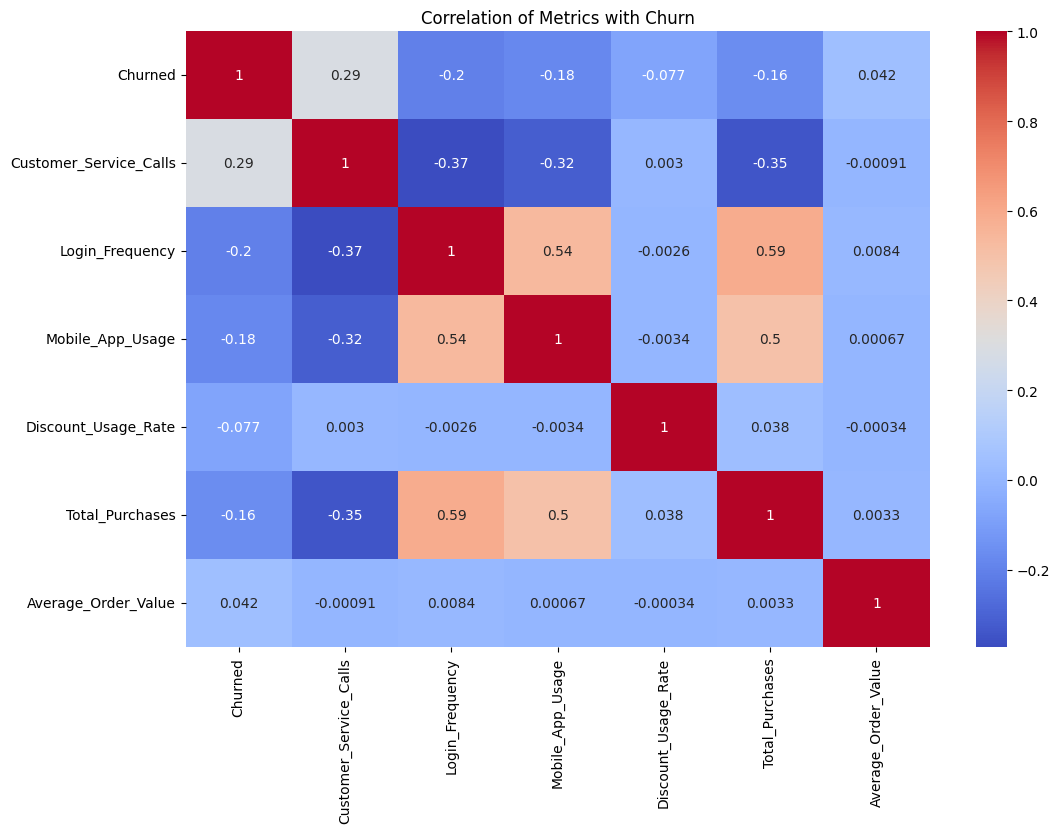

Number of High-Value Customers lost: 4992
Avg Service Calls for lost High-Value customers: 7.07


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Handling Missing Values for Analysis
# For categorical/scores, let's fill with 0 or 'Unknown' to see if 'Missing' itself is a signal
df['Mobile_App_Usage'] = df['Mobile_App_Usage'].fillna(0)
df['Social_Media_Engagement_Score'] = df['Social_Media_Engagement_Score'].fillna(0)

# 2. Support Calls vs Churn (Finding the Friction Point)
plt.figure(figsize=(10, 6))
sns.barplot(x='Churned', y='Customer_Service_Calls', data=df)
plt.title('Avg Customer Service Calls: Retained vs Churned')
plt.show()

# 3. Correlation Heatmap
# This helps a PM see which levers actually move the needle on Churn
plt.figure(figsize=(12, 8))
correlation_matrix = df[['Churned', 'Customer_Service_Calls', 'Login_Frequency',
                         'Mobile_App_Usage', 'Discount_Usage_Rate', 'Total_Purchases', 'Average_Order_Value']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation of Metrics with Churn')
plt.show()

# 4. Identifying the "At-Risk High Value" Segment
# Defining "High Value" as Top 25% of AOV
high_value_threshold = df['Average_Order_Value'].quantile(0.75)
high_value_at_risk = df[(df['Average_Order_Value'] > high_value_threshold) & (df['Churned'] == 1)]

print(f"Number of High-Value Customers lost: {len(high_value_at_risk)}")
print(f"Avg Service Calls for lost High-Value customers: {high_value_at_risk['Customer_Service_Calls'].mean():.2f}")

In [3]:
# 1. Create RFM Segments
# Recency: Lower is better, Frequency: Higher is better, Monetary: Higher is better

# Create quartiles for RFM
df['R_Score'] = pd.qcut(df['Days_Since_Last_Purchase'], 4, labels=[4, 3, 2, 1]) # 4 is most recent
df['F_Score'] = pd.qcut(df['Total_Purchases'], 4, labels=[1, 2, 3, 4]) # 4 is most frequent
df['M_Score'] = pd.qcut(df['Lifetime_Value'], 4, labels=[1, 2, 3, 4]) # 4 is highest spend

# Calculate RFM Score
df['RFM_Segment'] = df['R_Score'].astype(str) + df['F_Score'].astype(str) + df['M_Score'].astype(str)

# 2. Define PM-Friendly Segments
def segment_me(row):
    if row['RFM_Segment'] == '444':
        return 'Champions'
    elif row['M_Score'] == 4 and row['R_Score'] == 1:
        return 'At-Risk Whales'
    elif row['R_Score'] == 4 and row['F_Score'] == 1:
        return 'New Potential'
    elif row['R_Score'] == 1 and row['F_Score'] == 1:
        return 'Lost/Cheap'
    else:
        return 'Regulars'

df['Customer_Segment'] = df.apply(segment_me, axis=1)

# 3. Analyze Churn and Service Calls by Segment
segment_analysis = df.groupby('Customer_Segment').agg({
    'Churned': 'mean',
    'Customer_Service_Calls': 'mean',
    'Lifetime_Value': 'mean',
    'Login_Frequency': 'count'
}).rename(columns={'Login_Frequency': 'User_Count'})

print(segment_analysis)

                   Churned  Customer_Service_Calls  Lifetime_Value  User_Count
Customer_Segment                                                              
At-Risk Whales    0.414197                4.617373     2707.034983        2902
Champions         0.296556                3.913501     2886.308821        1713
Lost/Cheap        0.682389                6.877091      669.445368        2947
New Potential     0.305897                6.844534      682.001192        3256
Regulars          0.248405                5.652604     1404.670530       39182


In [4]:
# We want to see how engagement differs for our top 2 segments
focus_segments = ['At-Risk Whales', 'New Potential', 'Champions']
deep_dive = df[df['Customer_Segment'].isin(focus_segments)].groupby('Customer_Segment').agg({
    'Discount_Usage_Rate': 'mean',
    'Email_Open_Rate': 'mean',
    'Mobile_App_Usage': 'mean',
    'Login_Frequency': 'mean'
})

print(deep_dive)

# Let's check the 'Aha Moment'
# Correlation between Login_Frequency and Churn specifically for 'New Potential'
new_potential_df = df[df['Customer_Segment'] == 'New Potential']
print(f"\nCorrelation of Login Frequency to Churn for New Users: {new_potential_df['Login_Frequency'].corr(df['Churned']):.2f}")

                  Discount_Usage_Rate  Email_Open_Rate  Mobile_App_Usage  \
Customer_Segment                                                           
At-Risk Whales              41.436057        29.619958         23.816506   
Champions                   42.716725        36.134824         27.470228   
New Potential               40.633419        10.264084         10.302211   

                  Login_Frequency  
Customer_Segment                   
At-Risk Whales          16.860441  
Champions               20.220082  
New Potential            5.626843  

Correlation of Login Frequency to Churn for New Users: -0.20


<Figure size 1200x600 with 0 Axes>

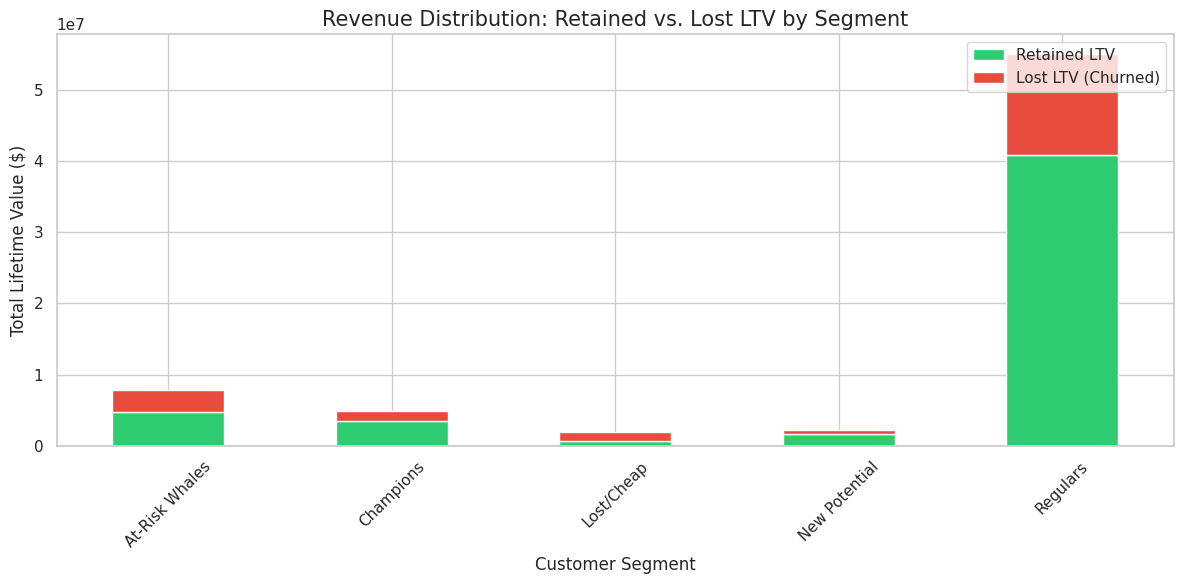

/tmp/ipykernel_839/2263581495.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_calls = df.groupby('Service_Call_Bins')['Churned'].mean()


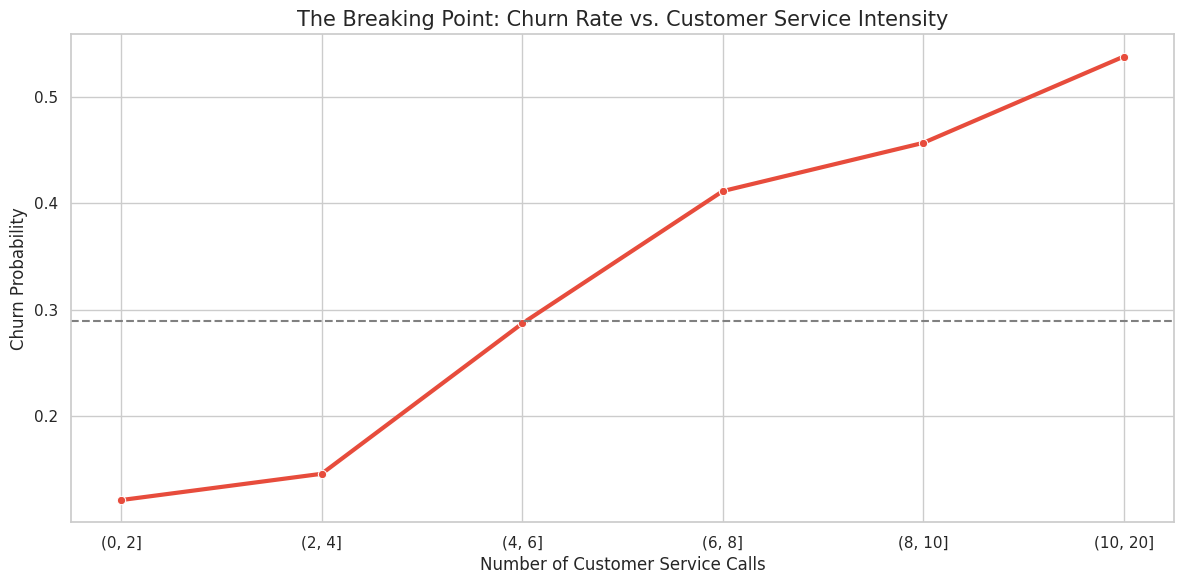

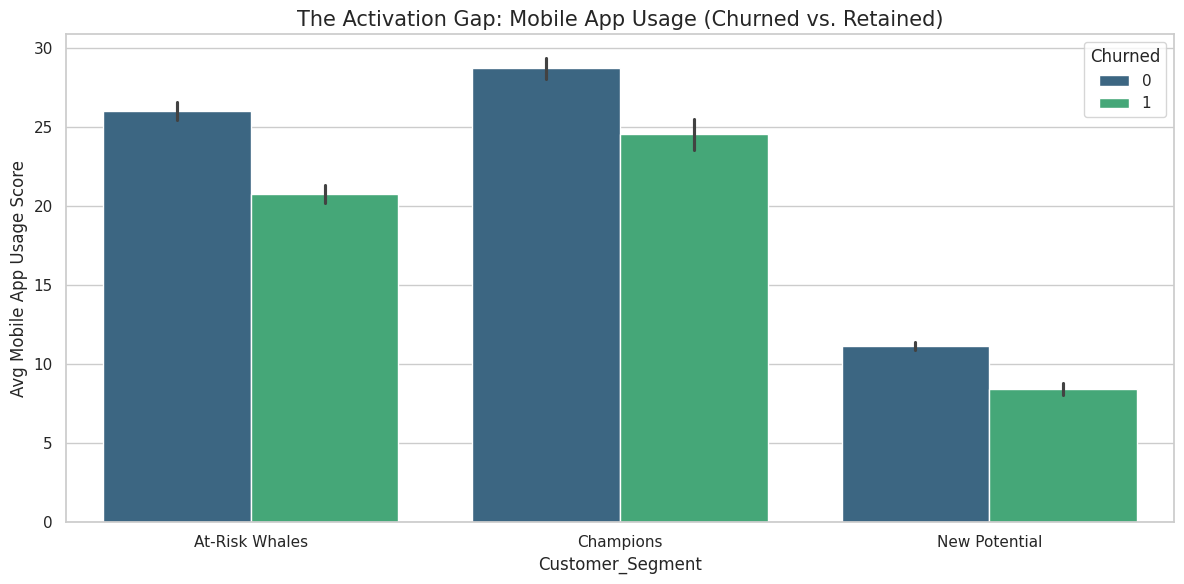

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

# 1. VISUAL: The "Revenue at Risk" (Why this matters)
# Total LTV per segment, colored by churn status
plt.figure()
revenue_plot = df.groupby(['Customer_Segment', 'Churned'])['Lifetime_Value'].sum().unstack()
revenue_plot.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'])
plt.title('Revenue Distribution: Retained vs. Lost LTV by Segment', fontsize=15)
plt.ylabel('Total Lifetime Value ($)')
plt.xlabel('Customer Segment')
plt.legend(['Retained LTV', 'Lost LTV (Churned)'], loc='upper right')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('revenue_at_risk.png')
plt.show()

# 2. VISUAL: The "Support Breaking Point" (The Evidence)
# A line plot showing Churn Rate vs Number of Service Calls
plt.figure()
# Binning service calls to see the trend clearly
df['Service_Call_Bins'] = pd.cut(df['Customer_Service_Calls'], bins=[0, 2, 4, 6, 8, 10, 20])
churn_by_calls = df.groupby('Service_Call_Bins')['Churned'].mean()
sns.lineplot(x=churn_by_calls.index.astype(str), y=churn_by_calls.values, marker='o', color='#e74c3c', linewidth=3)
plt.axhline(df['Churned'].mean(), linestyle='--', color='gray', label='Avg Churn Rate')
plt.title('The Breaking Point: Churn Rate vs. Customer Service Intensity', fontsize=15)
plt.ylabel('Churn Probability')
plt.xlabel('Number of Customer Service Calls')
plt.tight_layout()
plt.savefig('breaking_point.png')
plt.show()

# 3. VISUAL: The "Activation Gap" (The Solution)
# Comparing Mobile App Usage across key segments
plt.figure()
activation_data = df[df['Customer_Segment'].isin(['Champions', 'New Potential', 'At-Risk Whales'])]
sns.barplot(x='Customer_Segment', y='Mobile_App_Usage', hue='Churned', data=activation_data, palette='viridis')
plt.title('The Activation Gap: Mobile App Usage (Churned vs. Retained)', fontsize=15)
plt.ylabel('Avg Mobile App Usage Score')
plt.tight_layout()
plt.savefig('activation_gap.png')
plt.show()